# OOD Detection Analysis: Epistemic vs Total Uncertainty

This notebook analyzes Out-of-Distribution (OOD) detection performance using a model trained on CIFAR-10.

**OOD Datasets:**
- **SVHN** (Street View House Numbers)
- **Food-101** (Food images)
- **Stanford Cars** (Car images)

We compare uncertainty distributions when using:
1. **Total Uncertainty** (Epistemic + Aleatoric)
2. **Epistemic Uncertainty Only**

The goal is to understand how each type of uncertainty contributes to OOD detection.

## Setup and Imports

In [1]:
import os
import sys

# Add the 'build' directory to sys.path
sys.path.append(
    os.path.normpath(os.path.join(os.path.dirname(os.getcwd()), "build"))
)

import numpy as np
from scipy.stats import norm, gaussian_kde
import torch
import torchvision
import torchvision.transforms.v2 as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm import tqdm

import pytagi
from tagi_resnet_model import resnet18_cifar10

# NEW: Import calibration utilities
from calibration_utils import (
    remax_analytical, collect_logits, softmax_analytical,
    load_calibration_params
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

print(f"PyTAGI CUDA available: {pytagi.cuda.is_available()}")

/home/mf2/.miniconda3/envs/cuTAGI/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


PyTAGI CUDA available: True


## Configuration

In [2]:
# Configuration
CHECKPOINT_PATH = "../checkpoints/calibration_run/best_model_1_1.bin"
BATCH_SIZE = 128
NUM_CLASSES = 10

# # Load optimized calibration parameters from file if available
# try:
#     SCALE, SHIFT = load_calibration_params("../checkpoints/calibration_run/calibration_results.txt")
#     print(f"Loaded calibration params: SCALE={SCALE:.4f}, SHIFT={SHIFT:.4f}")
# except:
#     print("Could not load calibration params, using defaults/hardcoded values.")
#     SCALE = 3.4466 
#     SHIFT = 7.5952


# SCALE = 1.0
# SHIFT = 0.0
# SCALE = 10.0
# SHIFT = 9.0

# Softmax
# SCALE = 3.2706
# SHIFT = 0.0048

# Remax
SCALE = 10.3373
SHIFT = 9.4423


# Dataset normalization constants
NORMALIZATION_MEAN = [0.4914, 0.4822, 0.4465]
NORMALIZATION_STD = [0.2470, 0.2435, 0.2616]

# CIFAR-10 class names
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

## Analytical Remax Functions

**Note:** `remax_analytical` and other helper functions are now imported from `calibration_utils.py`.

## Utility Functions

In [3]:
def calculate_entropy(probs):
    """Calculates entropy of the probability distribution."""
    epsilon = 1e-10
    return -np.sum(probs * np.log(probs + epsilon), axis=1)

def calculate_total_variance(sigma_a_sq):
    """Calculates total variance (sum of variances across classes)."""
    return np.sum(sigma_a_sq, axis=1)

def calculate_logit_entropy(logit_variance):
    """
    Calculates differential entropy of logits modeled as Gaussian distributions.
    
    For a Gaussian with variance σ², differential entropy is:
    h(X) = 0.5 * log(2 * π * e * σ²)
    
    We sum this across all classes to get total logit entropy.
    """
    epsilon = 1e-10
    # Differential entropy for each logit (Gaussian)
    # h = 0.5 * log(2 * π * e * σ²) = 0.5 * (log(2πe) + log(σ²))
    log_2_pi_e = np.log(2 * np.pi * np.e)
    # Ensure variance is positive
    logit_variance = np.maximum(logit_variance, epsilon)
    differential_entropy = 0.5 * (log_2_pi_e + np.log(logit_variance))
    # Sum across all classes
    return np.sum(differential_entropy, axis=1)

def calculate_logit_variance_sum(logit_variance):
    """
    Calculates total logit variance (sum of variances across classes). 
    """
    return np.sum(logit_variance, axis=1)

def custom_collate_fn(batch):
    """Custom collate function to match training format."""
    batch_images, batch_labels = zip(*batch)
    batch_images = torch.stack(batch_images)
    batch_labels = torch.tensor(batch_labels)
    batch_images = batch_images.reshape(-1)
    batch_images = batch_images.numpy()
    return batch_images, batch_labels

## Load Datasets (CIFAR-10, SVHN, Food-101, and Stanford Cars)

In [4]:
def get_dataloaders():
    """Load CIFAR-10 (ID), SVHN (OOD), Food-101 (OOD), and Stanford Cars (OOD) test datasets."""
    
    # Transform for all datasets (using CIFAR-10 normalization)
    transform = transforms.Compose([
        transforms.ToImage(),
        transforms.ConvertImageDtype(torch.float32),
        transforms.Normalize(mean=NORMALIZATION_MEAN, std=NORMALIZATION_STD),
    ])
    
    # CIFAR-10 (In-Distribution)
    cifar_set = torchvision.datasets.CIFAR10(
        root="../data/cifar",
        train=False,
        download=True,
        transform=transform,
    )
    cifar_loader = DataLoader(
        cifar_set,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=True,
        num_workers=1,
        collate_fn=custom_collate_fn,
    )
    
    # SVHN (Out-Of-Distribution)
    svhn_set = torchvision.datasets.SVHN(
        root="../data/svhn",
        split='test',
        download=True,
        transform=transform,
    )
    svhn_loader = DataLoader(
        svhn_set,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=True,
        num_workers=1,
        collate_fn=custom_collate_fn,
    )
    
    # Food-101 (Out-Of-Distribution)
    # Note: Food-101 images are larger, so we resize them to 32x32 like CIFAR-10
    transform_resized = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToImage(),
        transforms.ConvertImageDtype(torch.float32),
        transforms.Normalize(mean=NORMALIZATION_MEAN, std=NORMALIZATION_STD),
    ])
    
    food_set = torchvision.datasets.Food101(
        root="../data/food101",
        split='test',
        download=True,
        transform=transform_resized,
    )
    food_loader = DataLoader(
        food_set,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=True,
        num_workers=1,
        collate_fn=custom_collate_fn,
    )
    
    # Stanford Cars (Out-Of-Distribution)
    # Note: Stanford Cars images are larger, so we resize them to 32x32 like CIFAR-10
    # Try with download=False first since we have the data manually downloaded
    cars_loader = None
    try:
        cars_set = torchvision.datasets.StanfordCars(
            root="../data/stanford_cars",
            split='test',
            download=False,  # Changed to False since we have the data
            transform=transform_resized,
        )
        cars_loader = DataLoader(
            cars_set,
            batch_size=BATCH_SIZE,
            shuffle=False,
            drop_last=True,
            num_workers=1,
            collate_fn=custom_collate_fn,
        )
        print(f"✓ Loaded Stanford Cars using torchvision.datasets.StanfordCars")
    except Exception as e:
        print(f"Note: torchvision.datasets.StanfordCars failed: {e}")
        print("Attempting to load Stanford Cars using custom ImageFolder approach...")
        
        # Try using ImageFolder with the nested structure
        import os
        from torchvision.datasets import ImageFolder
        
        # Check different possible paths
        possible_paths = [
            "../data/stanford_cars/cars_test/cars_test",
            "../data/stanford_cars/cars_test",
            "../data/stanford_cars",
        ]
        
        for test_path in possible_paths:
            if os.path.exists(test_path):
                try:
                    # Check if it's a directory with images
                    if os.path.isdir(test_path):
                        files = os.listdir(test_path)
                        image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                        
                        if image_files:
                            # Create a simple dataset from the images
                            from torch.utils.data import Dataset
                            from PIL import Image
                            
                            class StanfordCarsSimple(Dataset):
                                def __init__(self, image_dir, transform=None):
                                    self.image_dir = image_dir
                                    self.transform = transform
                                    self.images = sorted([f for f in os.listdir(image_dir) 
                                                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                                
                                def __len__(self):
                                    return len(self.images)
                                
                                def __getitem__(self, idx):
                                    img_path = os.path.join(self.image_dir, self.images[idx])
                                    image = Image.open(img_path).convert('RGB')
                                    if self.transform:
                                        image = self.transform(image)
                                    # Return dummy label (0) since we only care about OOD detection
                                    return image, 0
                            
                            cars_set = StanfordCarsSimple(test_path, transform=transform_resized)
                            cars_loader = DataLoader(
                                cars_set,
                                batch_size=BATCH_SIZE,
                                shuffle=False,
                                drop_last=True,
                                num_workers=1,
                                collate_fn=custom_collate_fn,
                            )
                            print(f"✓ Successfully loaded Stanford Cars from: {test_path}")
                            print(f"  Found {len(cars_set)} images")
                            break
                except Exception as inner_e:
                    print(f"  Failed to load from {test_path}: {inner_e}")
                    continue
        
        if cars_loader is None:
            print("⚠ Could not load Stanford Cars dataset")
            print("  Please check the directory structure in ../data/stanford_cars/")
    
    return cifar_loader, svhn_loader, food_loader, cars_loader

# Load the datasets
cifar_loader, svhn_loader, food_loader, cars_loader = get_dataloaders()
print(f"\nDataset Summary:")
print(f"  CIFAR-10 test set: {len(cifar_loader) * BATCH_SIZE} images")
print(f"  SVHN test set: {len(svhn_loader) * BATCH_SIZE} images")
print(f"  Food-101 test set: {len(food_loader) * BATCH_SIZE} images")
if cars_loader is not None:
    print(f"  Stanford Cars test set: {len(cars_loader) * BATCH_SIZE} images")
else:
    print("  Stanford Cars: Not loaded")

Files already downloaded and verified
Using downloaded and verified file: ../data/svhn/test_32x32.mat
Note: torchvision.datasets.StanfordCars failed: Dataset not found. Try to manually download following the instructions in https://github.com/pytorch/vision/issues/7545#issuecomment-1631441616.
Attempting to load Stanford Cars using custom ImageFolder approach...
✓ Successfully loaded Stanford Cars from: ../data/stanford_cars/cars_test/cars_test
  Found 8041 images

Dataset Summary:
  CIFAR-10 test set: 9984 images
  SVHN test set: 25984 images
  Food-101 test set: 25216 images
  Stanford Cars test set: 7936 images


## Load Trained Model

In [5]:
# Initialize network with same architecture as training
net = resnet18_cifar10(is_remax=False, gain_w=0.083, gain_b=0.083)
device = "cuda" if pytagi.cuda.is_available() else "cpu"
net.to_device(device)

# Load the trained model weights
net.load(CHECKPOINT_PATH)
net.eval()  # Set to evaluation mode

print(f"Model loaded from: {CHECKPOINT_PATH}")
print(f"Running on device: {device}")

Model loaded from: ../checkpoints/calibration_run/best_model_1_1.bin
Running on device: cuda


## Compute Uncertainty Metrics

We'll compute uncertainties using both:
1. **Total variance** = Epistemic variance + Aleatoric mean
2. **Epistemic variance only**

In [6]:
def get_uncertainty_metrics(net, loader, use_total_variance=True, description="Processing"):
    """
    Compute uncertainty metrics for a dataset using robust calibration utilities.
    
    Args:
        net: The neural network
        loader: DataLoader for the dataset
        use_total_variance: If True, use aleatoric + epistemic variance.
                           If False, use only epistemic variance.
        description: Description for progress bar
    
    Returns:
        Dictionary with:
            - prob_entropy: Entropy after Remax (probability-based)
            - prob_variance: Sum of probability variances after Remax
            - logit_entropy: Differential entropy of logits (Gaussian)
            - logit_variance: Sum of logit variances
    """
    
    all_prob_entropy = []
    all_prob_variance = []
    all_logit_entropy = []
    all_logit_variance = []
    
    net.eval()
    
    # Calibration constants matching calibration_utils defaults
    LOGIT_MIN = -40.0
    LOGIT_MAX = 30.0
    VAR_MAX = 1000.0
    
    for data, target in tqdm(loader, desc=description):
        # Forward pass
        m_pred_raw, v_pred_raw = net(data)
        
        # --- RESHAPE 1D -> 2D ---
        current_batch_size_actual = len(target)
        m_pred_2d = m_pred_raw.reshape(current_batch_size_actual, -1)
        v_pred_2d = v_pred_raw.reshape(current_batch_size_actual, -1)
        
        # --- SEPARATE COMPONENTS ---
        m_epistemic = m_pred_2d[:, ::2]   # [Batch, num_classes]
        v_epistemic = v_pred_2d[:, ::2]   # [Batch, num_classes]
        m_aleatoric = m_pred_2d[:, 1::2]  # [Batch, num_classes]
        
        # --- STEP 1: LOGIT CENTERING ---
        # row_means = np.mean(m_epistemic, axis=1, keepdims=True)
        # m_epistemic = m_epistemic - row_means
        
        # --- STEP 2: SCALING & SHIFTING ---
        m_epistemic_final = (m_epistemic * SCALE) + SHIFT
    
        
        # --- STEP 3: VARIANCE SCALING & SELECTION ---
        # Scale variances
        v_epistemic_scaled = v_epistemic * (SCALE ** 2)
        m_aleatoric_scaled = m_aleatoric * (SCALE ** 2)
        
        # Choose variance based on mode
        if use_total_variance:
            v_used = m_aleatoric_scaled + v_epistemic_scaled
        else:
            v_used = v_epistemic_scaled
            
        # Clip variance
        v_used = np.clip(v_used, 1e-6, VAR_MAX)
        
        # ============ LOGIT-BASED METRICS (before Remax) ============
        logit_entropy = calculate_logit_entropy(v_used)
        logit_variance = calculate_logit_variance_sum(v_used)
        all_logit_entropy.extend(logit_entropy)
        all_logit_variance.extend(logit_variance)
        
        # ============ PROBABILITY-BASED METRICS (after Remax) ============
        # Use vectorized remax_analytical from calibration_utils
        remax_out = remax_analytical(m_epistemic_final, v_used)
        # remax_out = softmax_analytical(m_epistemic_final, v_used)
        
        probs = remax_out['mu_a']
        # Normalize probabilities (just in case)
        row_sums = probs.sum(axis=1, keepdims=True)
        probs = probs / row_sums
        
        variances = remax_out['sigma_a_sq']
        
        prob_entropy = calculate_entropy(probs)
        prob_variance = calculate_total_variance(variances)
        
        all_prob_entropy.extend(prob_entropy)
        all_prob_variance.extend(prob_variance)
    
    return {
        'prob_entropy': np.array(all_prob_entropy),
        'prob_variance': np.array(all_prob_variance),
        'logit_entropy': np.array(all_logit_entropy),
        'logit_variance': np.array(all_logit_variance),
    }

## Compute Metrics for All Datasets

In [7]:
print("Computing uncertainties using TOTAL variance (Epistemic + Aleatoric)...")
print("\nCIFAR-10 (In-Distribution):")
cifar_total = get_uncertainty_metrics(
    net, cifar_loader, use_total_variance=True, description="CIFAR-10 (Total)"
)

print("\nSVHN (Out-of-Distribution):")
svhn_total = get_uncertainty_metrics(
    net, svhn_loader, use_total_variance=True, description="SVHN (Total)"
)

print("\nFood-101 (Out-of-Distribution):")
food_total = get_uncertainty_metrics(
    net, food_loader, use_total_variance=True, description="Food-101 (Total)"
)

if cars_loader is not None:
    print("\nStanford Cars (Out-of-Distribution):")
    cars_total = get_uncertainty_metrics(
        net, cars_loader, use_total_variance=True, description="Stanford Cars (Total)"
    )
else:
    cars_total = None


Computing uncertainties using TOTAL variance (Epistemic + Aleatoric)...

CIFAR-10 (In-Distribution):


CIFAR-10 (Total): 100%|██████████| 78/78 [00:05<00:00, 14.00it/s]



SVHN (Out-of-Distribution):


SVHN (Total): 100%|██████████| 203/203 [00:11<00:00, 17.38it/s]



Food-101 (Out-of-Distribution):


Food-101 (Total): 100%|██████████| 197/197 [01:06<00:00,  2.94it/s]



Stanford Cars (Out-of-Distribution):


Stanford Cars (Total): 100%|██████████| 62/62 [00:42<00:00,  1.47it/s]


In [8]:
print("Computing uncertainties using EPISTEMIC variance only...")
print("\nCIFAR-10 (In-Distribution):")
cifar_epistemic = get_uncertainty_metrics(
    net, cifar_loader, use_total_variance=False, description="CIFAR-10 (Epistemic)"
)

print("\nSVHN (Out-of-Distribution):")
svhn_epistemic = get_uncertainty_metrics(
    net, svhn_loader, use_total_variance=False, description="SVHN (Epistemic)"
)

print("\nFood-101 (Out-of-Distribution):")
food_epistemic = get_uncertainty_metrics(
    net, food_loader, use_total_variance=False, description="Food-101 (Epistemic)"
)

if cars_loader is not None:
    print("\nStanford Cars (Out-of-Distribution):")
    cars_epistemic = get_uncertainty_metrics(
        net, cars_loader, use_total_variance=False, description="Stanford Cars (Epistemic)"
    )
else:
    cars_epistemic = None


Computing uncertainties using EPISTEMIC variance only...

CIFAR-10 (In-Distribution):


CIFAR-10 (Epistemic): 100%|██████████| 78/78 [00:04<00:00, 15.77it/s]



SVHN (Out-of-Distribution):


SVHN (Epistemic): 100%|██████████| 203/203 [00:12<00:00, 16.82it/s]



Food-101 (Out-of-Distribution):


Food-101 (Epistemic): 100%|██████████| 197/197 [01:05<00:00,  3.00it/s]



Stanford Cars (Out-of-Distribution):


Stanford Cars (Epistemic): 100%|██████████| 62/62 [00:41<00:00,  1.49it/s]


## Visualization: Probability Entropy Distributions (After Remax)

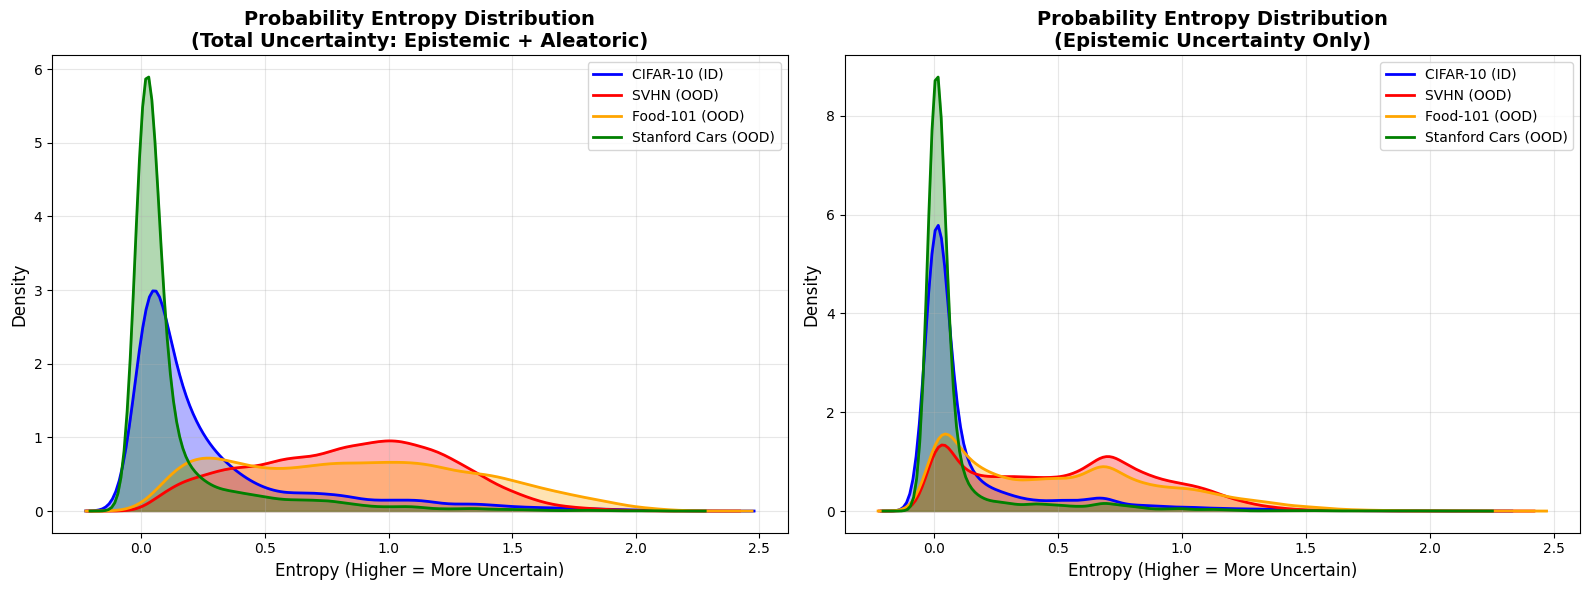


Plot saved to: ood_prob_entropy_comparison.png


In [9]:
def plot_kde(ax, data, color, label, fill_alpha=0.3):
    """Plot KDE with fill."""
    if len(data) > 1 and np.std(data) > 0:
        density = gaussian_kde(data)
        min_val, max_val = min(data), max(data)
        range_val = max_val - min_val
        xs = np.linspace(min_val - 0.1 * range_val, max_val + 0.1 * range_val, 200)
        ys = density(xs)
        ax.plot(xs, ys, color=color, label=label, linewidth=2)
        ax.fill_between(xs, ys, color=color, alpha=fill_alpha)
    else:
        ax.hist(data, bins=50, alpha=0.5, density=True, label=label, color=color)

# ============ PROBABILITY-BASED ENTROPY ============
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Total Variance
ax1 = axes[0]
plot_kde(ax1, cifar_total['prob_entropy'], 'blue', 'CIFAR-10 (ID)')
plot_kde(ax1, svhn_total['prob_entropy'], 'red', 'SVHN (OOD)')
plot_kde(ax1, food_total['prob_entropy'], 'orange', 'Food-101 (OOD)')
if cars_total is not None:
    plot_kde(ax1, cars_total['prob_entropy'], 'green', 'Stanford Cars (OOD)')
ax1.set_title('Probability Entropy Distribution\n(Total Uncertainty: Epistemic + Aleatoric)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Entropy (Higher = More Uncertain)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Epistemic Only
ax2 = axes[1]
plot_kde(ax2, cifar_epistemic['prob_entropy'], 'blue', 'CIFAR-10 (ID)')
plot_kde(ax2, svhn_epistemic['prob_entropy'], 'red', 'SVHN (OOD)')
plot_kde(ax2, food_epistemic['prob_entropy'], 'orange', 'Food-101 (OOD)')
if cars_epistemic is not None:
    plot_kde(ax2, cars_epistemic['prob_entropy'], 'green', 'Stanford Cars (OOD)')
ax2.set_title('Probability Entropy Distribution\n(Epistemic Uncertainty Only)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Entropy (Higher = More Uncertain)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('ood_prob_entropy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: ood_prob_entropy_comparison.png")

## Visualization: Logit Entropy Distributions (Before Remax)

This shows the differential entropy of the logit distributions (Gaussian).

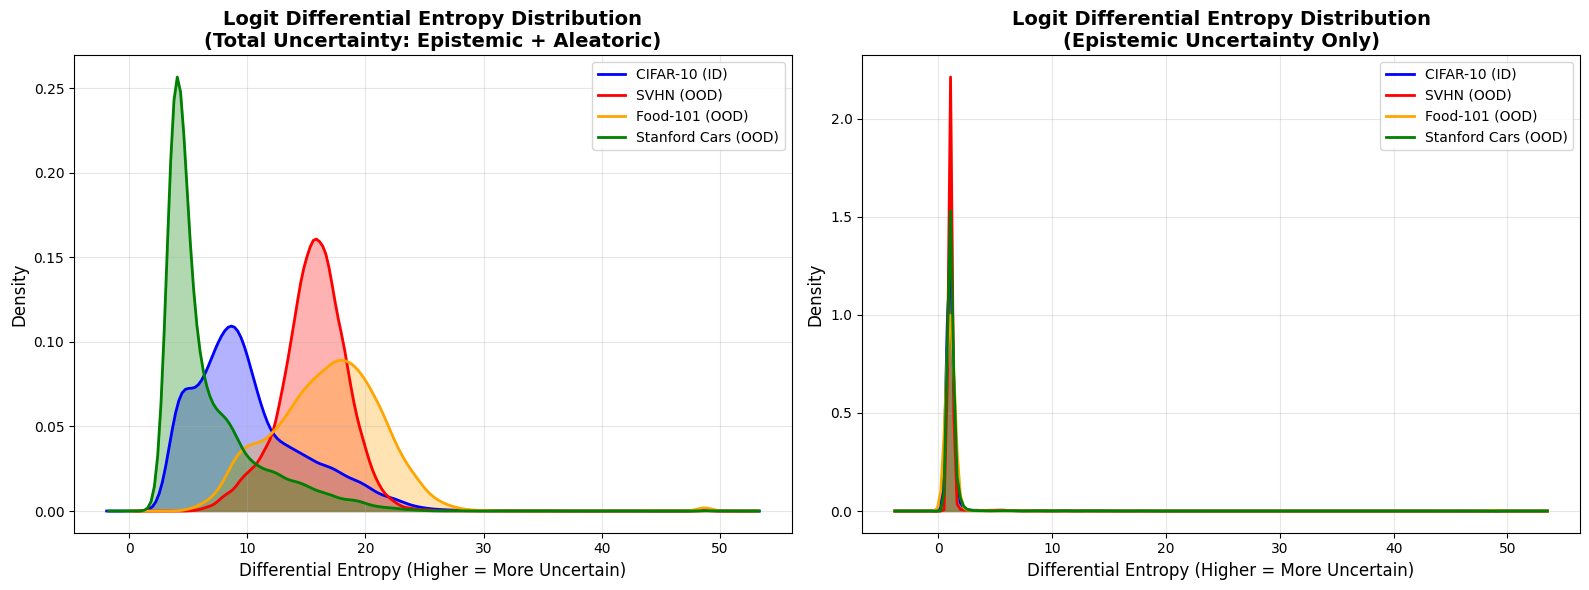


Plot saved to: ood_logit_entropy_comparison.png


In [10]:
# ============ LOGIT-BASED ENTROPY ============
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Total Variance
ax1 = axes[0]
plot_kde(ax1, cifar_total['logit_entropy'], 'blue', 'CIFAR-10 (ID)')
plot_kde(ax1, svhn_total['logit_entropy'], 'red', 'SVHN (OOD)')
plot_kde(ax1, food_total['logit_entropy'], 'orange', 'Food-101 (OOD)')
if cars_total is not None:
    plot_kde(ax1, cars_total['logit_entropy'], 'green', 'Stanford Cars (OOD)')
ax1.set_title('Logit Differential Entropy Distribution\n(Total Uncertainty: Epistemic + Aleatoric)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Differential Entropy (Higher = More Uncertain)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Epistemic Only
ax2 = axes[1]
plot_kde(ax2, cifar_epistemic['logit_entropy'], 'blue', 'CIFAR-10 (ID)')
plot_kde(ax2, svhn_epistemic['logit_entropy'], 'red', 'SVHN (OOD)')
plot_kde(ax2, food_epistemic['logit_entropy'], 'orange', 'Food-101 (OOD)')
if cars_epistemic is not None:
    plot_kde(ax2, cars_epistemic['logit_entropy'], 'green', 'Stanford Cars (OOD)')
ax2.set_title('Logit Differential Entropy Distribution\n(Epistemic Uncertainty Only)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Differential Entropy (Higher = More Uncertain)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('ood_logit_entropy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: ood_logit_entropy_comparison.png")

## Visualization: Total Probability Variance Distributions

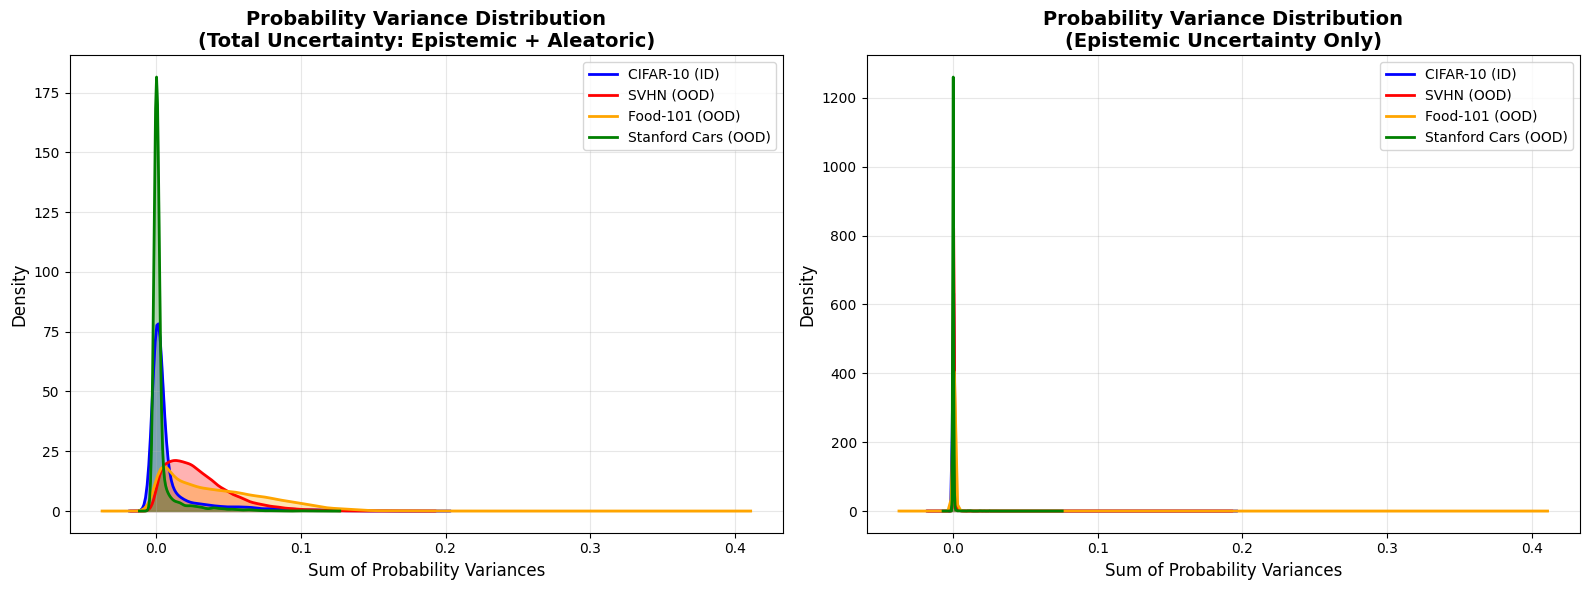


Plot saved to: ood_prob_variance_comparison.png


In [11]:
# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Total Variance
ax1 = axes[0]
plot_kde(ax1, cifar_total['prob_variance'], 'blue', 'CIFAR-10 (ID)')
plot_kde(ax1, svhn_total['prob_variance'], 'red', 'SVHN (OOD)')
plot_kde(ax1, food_total['prob_variance'], 'orange', 'Food-101 (OOD)')
if cars_total is not None:
    plot_kde(ax1, cars_total['prob_variance'], 'green', 'Stanford Cars (OOD)')
ax1.set_title('Probability Variance Distribution\n(Total Uncertainty: Epistemic + Aleatoric)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sum of Probability Variances', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Epistemic Only
ax2 = axes[1]
plot_kde(ax2, cifar_epistemic['prob_variance'], 'blue', 'CIFAR-10 (ID)')
plot_kde(ax2, svhn_epistemic['prob_variance'], 'red', 'SVHN (OOD)')
plot_kde(ax2, food_epistemic['prob_variance'], 'orange', 'Food-101 (OOD)')
if cars_epistemic is not None:
    plot_kde(ax2, cars_epistemic['prob_variance'], 'green', 'Stanford Cars (OOD)')
ax2.set_title('Probability Variance Distribution\n(Epistemic Uncertainty Only)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sum of Probability Variances', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('ood_prob_variance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: ood_prob_variance_comparison.png")

## Visualization: Logit Variance Distributions

This shows the sum of variances in the logit space (before Remax).

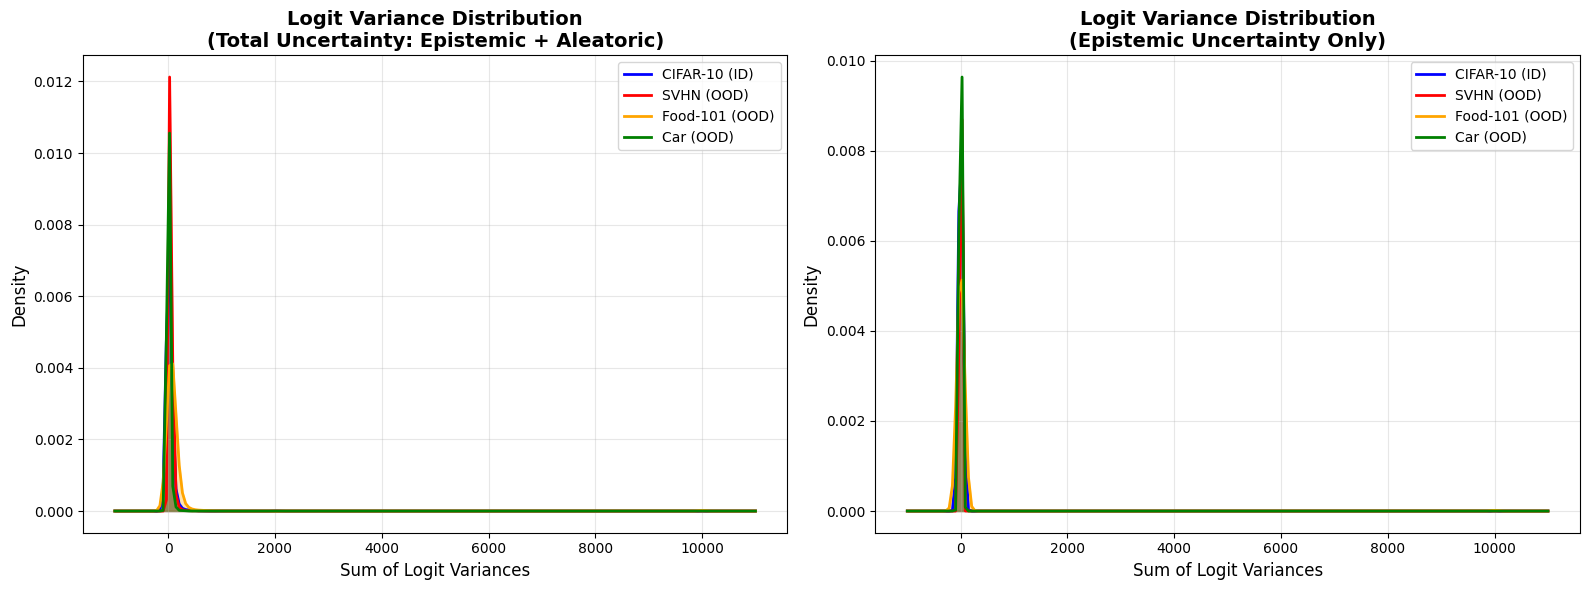


Plot saved to: ood_logit_variance_comparison.png


In [13]:
# ============ LOGIT VARIANCE ============
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Total Variance
ax1 = axes[0]
plot_kde(ax1, cifar_total['logit_variance'], 'blue', 'CIFAR-10 (ID)')
plot_kde(ax1, svhn_total['logit_variance'], 'red', 'SVHN (OOD)')
plot_kde(ax1, food_total['logit_variance'], 'orange', 'Food-101 (OOD)')
plot_kde(ax1, cars_total['logit_variance'], 'green', 'Car (OOD)')
ax1.set_title('Logit Variance Distribution\n(Total Uncertainty: Epistemic + Aleatoric)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sum of Logit Variances', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Epistemic Only
ax2 = axes[1]
plot_kde(ax2, cifar_epistemic['logit_variance'], 'blue', 'CIFAR-10 (ID)')
plot_kde(ax2, svhn_epistemic['logit_variance'], 'red', 'SVHN (OOD)')
plot_kde(ax2, food_epistemic['logit_variance'], 'orange', 'Food-101 (OOD)')
plot_kde(ax2, cars_epistemic['logit_variance'], 'green', 'Car (OOD)')
ax2.set_title('Logit Variance Distribution\n(Epistemic Uncertainty Only)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sum of Logit Variances', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('ood_logit_variance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: ood_logit_variance_comparison.png")

## Summary Statistics

In [15]:
print("=" * 90)
print("ROBUST UNCERTAINTY STATISTICS (MEDIAN-BASED)")
print("=" * 90)

print("\n" + "-" * 90)
print("TOTAL UNCERTAINTY (Epistemic + Aleatoric)")
print("-" * 90)

# Changed 'Mean' to 'Median' in the header
print(f"\n{'Metric':<30} {'Dataset':<15} {'Median':>12} {'Std':>12} {'Separation':>12}")
print("-" * 90)

# Probability Entropy
print(f"{'Prob. Entropy':<30} {'CIFAR-10 (ID)':<15} {np.median(cifar_total['prob_entropy']):>12.4f} {np.std(cifar_total['prob_entropy']):>12.4f}")
print(f"{'':<30} {'SVHN (OOD)':<15} {np.median(svhn_total['prob_entropy']):>12.4f} {np.std(svhn_total['prob_entropy']):>12.4f} {np.median(svhn_total['prob_entropy']) - np.median(cifar_total['prob_entropy']):>12.4f}")
print(f"{'':<30} {'Food-101 (OOD)':<15} {np.median(food_total['prob_entropy']):>12.4f} {np.std(food_total['prob_entropy']):>12.4f} {np.median(food_total['prob_entropy']) - np.median(cifar_total['prob_entropy']):>12.4f}")
print(f"{'':<30} {'Stanford Cars (OOD)':<15} {np.median(cars_total['prob_entropy']):>12.4f} {np.std(cars_total['prob_entropy']):>12.4f} {np.median(cars_total['prob_entropy']) - np.median(cifar_total['prob_entropy']):>12.4f}")

# Logit Entropy
print(f"{'Logit Entropy':<30} {'CIFAR-10 (ID)':<15} {np.median(cifar_total['logit_entropy']):>12.4f} {np.std(cifar_total['logit_entropy']):>12.4f}")
print(f"{'':<30} {'SVHN (OOD)':<15} {np.median(svhn_total['logit_entropy']):>12.4f} {np.std(svhn_total['logit_entropy']):>12.4f} {np.median(svhn_total['logit_entropy']) - np.median(cifar_total['logit_entropy']):>12.4f}")
print(f"{'':<30} {'Food-101 (OOD)':<15} {np.median(food_total['logit_entropy']):>12.4f} {np.std(food_total['logit_entropy']):>12.4f} {np.median(food_total['logit_entropy']) - np.median(cifar_total['logit_entropy']):>12.4f}")
print(f"{'':<30} {'Stanford Cars (OOD)':<15} {np.median(cars_total['logit_entropy']):>12.4f} {np.std(cars_total['logit_entropy']):>12.4f} {np.median(cars_total['logit_entropy']) - np.median(cifar_total['logit_entropy']):>12.4f}")

# Probability Variance
print(f"{'Prob. Variance':<30} {'CIFAR-10 (ID)':<15} {np.median(cifar_total['prob_variance']):>12.6f} {np.std(cifar_total['prob_variance']):>12.6f}")
print(f"{'':<30} {'SVHN (OOD)':<15} {np.median(svhn_total['prob_variance']):>12.6f} {np.std(svhn_total['prob_variance']):>12.6f} {np.median(svhn_total['prob_variance']) - np.median(cifar_total['prob_variance']):>12.6f}")
print(f"{'':<30} {'Food-101 (OOD)':<15} {np.median(food_total['prob_variance']):>12.6f} {np.std(food_total['prob_variance']):>12.6f} {np.median(food_total['prob_variance']) - np.median(cifar_total['prob_variance']):>12.6f}")
print(f"{'':<30} {'Stanford Cars (OOD)':<15} {np.median(cars_total['prob_variance']):>12.6f} {np.std(cars_total['prob_variance']):>12.6f} {np.median(cars_total['prob_variance']) - np.median(cifar_total['prob_variance']):>12.6f}")

# Logit Variance
print(f"{'Logit Variance':<30} {'CIFAR-10 (ID)':<15} {np.median(cifar_total['logit_variance']):>12.4f} {np.std(cifar_total['logit_variance']):>12.4f}")
print(f"{'':<30} {'SVHN (OOD)':<15} {np.median(svhn_total['logit_variance']):>12.4f} {np.std(svhn_total['logit_variance']):>12.4f} {np.median(svhn_total['logit_variance']) - np.median(cifar_total['logit_variance']):>12.4f}")
print(f"{'':<30} {'Food-101 (OOD)':<15} {np.median(food_total['logit_variance']):>12.4f} {np.std(food_total['logit_variance']):>12.4f} {np.median(food_total['logit_variance']) - np.median(cifar_total['logit_variance']):>12.4f}")
print(f"{'':<30} {'Stanford Cars (OOD)':<15} {np.median(cars_total['logit_variance']):>12.4f} {np.std(cars_total['logit_variance']):>12.4f} {np.median(cars_total['logit_variance']) - np.median(cifar_total['logit_variance']):>12.4f}")

print("\n" + "-" * 90)
print("EPISTEMIC UNCERTAINTY ONLY")
print("-" * 90)

print(f"\n{'Metric':<30} {'Dataset':<15} {'Median':>12} {'Std':>12} {'Separation':>12}")
print("-" * 90)

# Probability Entropy
print(f"{'Prob. Entropy':<30} {'CIFAR-10 (ID)':<15} {np.median(cifar_epistemic['prob_entropy']):>12.4f} {np.std(cifar_epistemic['prob_entropy']):>12.4f}")
print(f"{'':<30} {'SVHN (OOD)':<15} {np.median(svhn_epistemic['prob_entropy']):>12.4f} {np.std(svhn_epistemic['prob_entropy']):>12.4f} {np.median(svhn_epistemic['prob_entropy']) - np.median(cifar_epistemic['prob_entropy']):>12.4f}")
print(f"{'':<30} {'Food-101 (OOD)':<15} {np.median(food_epistemic['prob_entropy']):>12.4f} {np.std(food_epistemic['prob_entropy']):>12.4f} {np.median(food_epistemic['prob_entropy']) - np.median(cifar_epistemic['prob_entropy']):>12.4f}")
print(f"{'':<30} {'Stanford Cars (OOD)':<15} {np.median(cars_epistemic['prob_entropy']):>12.4f} {np.std(cars_epistemic['prob_entropy']):>12.4f} {np.median(cars_epistemic['prob_entropy']) - np.median(cifar_epistemic['prob_entropy']):>12.4f}")

# Logit Entropy
print(f"{'Logit Entropy':<30} {'CIFAR-10 (ID)':<15} {np.median(cifar_epistemic['logit_entropy']):>12.4f} {np.std(cifar_epistemic['logit_entropy']):>12.4f}")
print(f"{'':<30} {'SVHN (OOD)':<15} {np.median(svhn_epistemic['logit_entropy']):>12.4f} {np.std(svhn_epistemic['logit_entropy']):>12.4f} {np.median(svhn_epistemic['logit_entropy']) - np.median(cifar_epistemic['logit_entropy']):>12.4f}")
print(f"{'':<30} {'Food-101 (OOD)':<15} {np.median(food_epistemic['logit_entropy']):>12.4f} {np.std(food_epistemic['logit_entropy']):>12.4f} {np.median(food_epistemic['logit_entropy']) - np.median(cifar_epistemic['logit_entropy']):>12.4f}")
print(f"{'':<30} {'Stanford Cars (OOD)':<15} {np.median(cars_epistemic['logit_entropy']):>12.4f} {np.std(cars_epistemic['logit_entropy']):>12.4f} {np.median(cars_epistemic['logit_entropy']) - np.median(cifar_epistemic['logit_entropy']):>12.4f}")

# Probability Variance
print(f"{'Prob. Variance':<30} {'CIFAR-10 (ID)':<15} {np.median(cifar_epistemic['prob_variance']):>12.6f} {np.std(cifar_epistemic['prob_variance']):>12.6f}")
print(f"{'':<30} {'SVHN (OOD)':<15} {np.median(svhn_epistemic['prob_variance']):>12.6f} {np.std(svhn_epistemic['prob_variance']):>12.6f} {np.median(svhn_epistemic['prob_variance']) - np.median(cifar_epistemic['prob_variance']):>12.6f}")
print(f"{'':<30} {'Food-101 (OOD)':<15} {np.median(food_epistemic['prob_variance']):>12.6f} {np.std(food_epistemic['prob_variance']):>12.6f} {np.median(food_epistemic['prob_variance']) - np.median(cifar_epistemic['prob_variance']):>12.6f}")
print(f"{'':<30} {'Stanford Cars (OOD)':<15} {np.median(cars_epistemic['prob_variance']):>12.6f} {np.std(cars_epistemic['prob_variance']):>12.6f} {np.median(cars_epistemic['prob_variance']) - np.median(cifar_epistemic['prob_variance']):>12.6f}")

# Logit Variance
print(f"{'Logit Variance':<30} {'CIFAR-10 (ID)':<15} {np.median(cifar_epistemic['logit_variance']):>12.4f} {np.std(cifar_epistemic['logit_variance']):>12.4f}")
print(f"{'':<30} {'SVHN (OOD)':<15} {np.median(svhn_epistemic['logit_variance']):>12.4f} {np.std(svhn_epistemic['logit_variance']):>12.4f} {np.median(svhn_epistemic['logit_variance']) - np.median(cifar_epistemic['logit_variance']):>12.4f}")
print(f"{'':<30} {'Food-101 (OOD)':<15} {np.median(food_epistemic['logit_variance']):>12.4f} {np.std(food_epistemic['logit_variance']):>12.4f} {np.median(food_epistemic['logit_variance']) - np.median(cifar_epistemic['logit_variance']):>12.4f}")
print(f"{'':<30} {'Stanford Cars (OOD)':<15} {np.median(cars_epistemic['logit_variance']):>12.4f} {np.std(cars_epistemic['logit_variance']):>12.4f} {np.median(cars_epistemic['logit_variance']) - np.median(cifar_epistemic['logit_variance']):>12.4f}")

print("\n" + "=" * 90)

ROBUST UNCERTAINTY STATISTICS (MEDIAN-BASED)

------------------------------------------------------------------------------------------
TOTAL UNCERTAINTY (Epistemic + Aleatoric)
------------------------------------------------------------------------------------------

Metric                         Dataset               Median          Std   Separation
------------------------------------------------------------------------------------------
Prob. Entropy                  CIFAR-10 (ID)         0.1260       0.3817
                               SVHN (OOD)            0.8701       0.3899       0.7441
                               Food-101 (OOD)        0.8461       0.4898       0.7201
                               Stanford Cars (OOD)       0.0335       0.2609      -0.0924
Logit Entropy                  CIFAR-10 (ID)         9.1067       4.8072
                               SVHN (OOD)           15.7385       2.8395       6.6318
                               Food-101 (OOD)       16.994

## OOD Detection Performance: ROC Curves

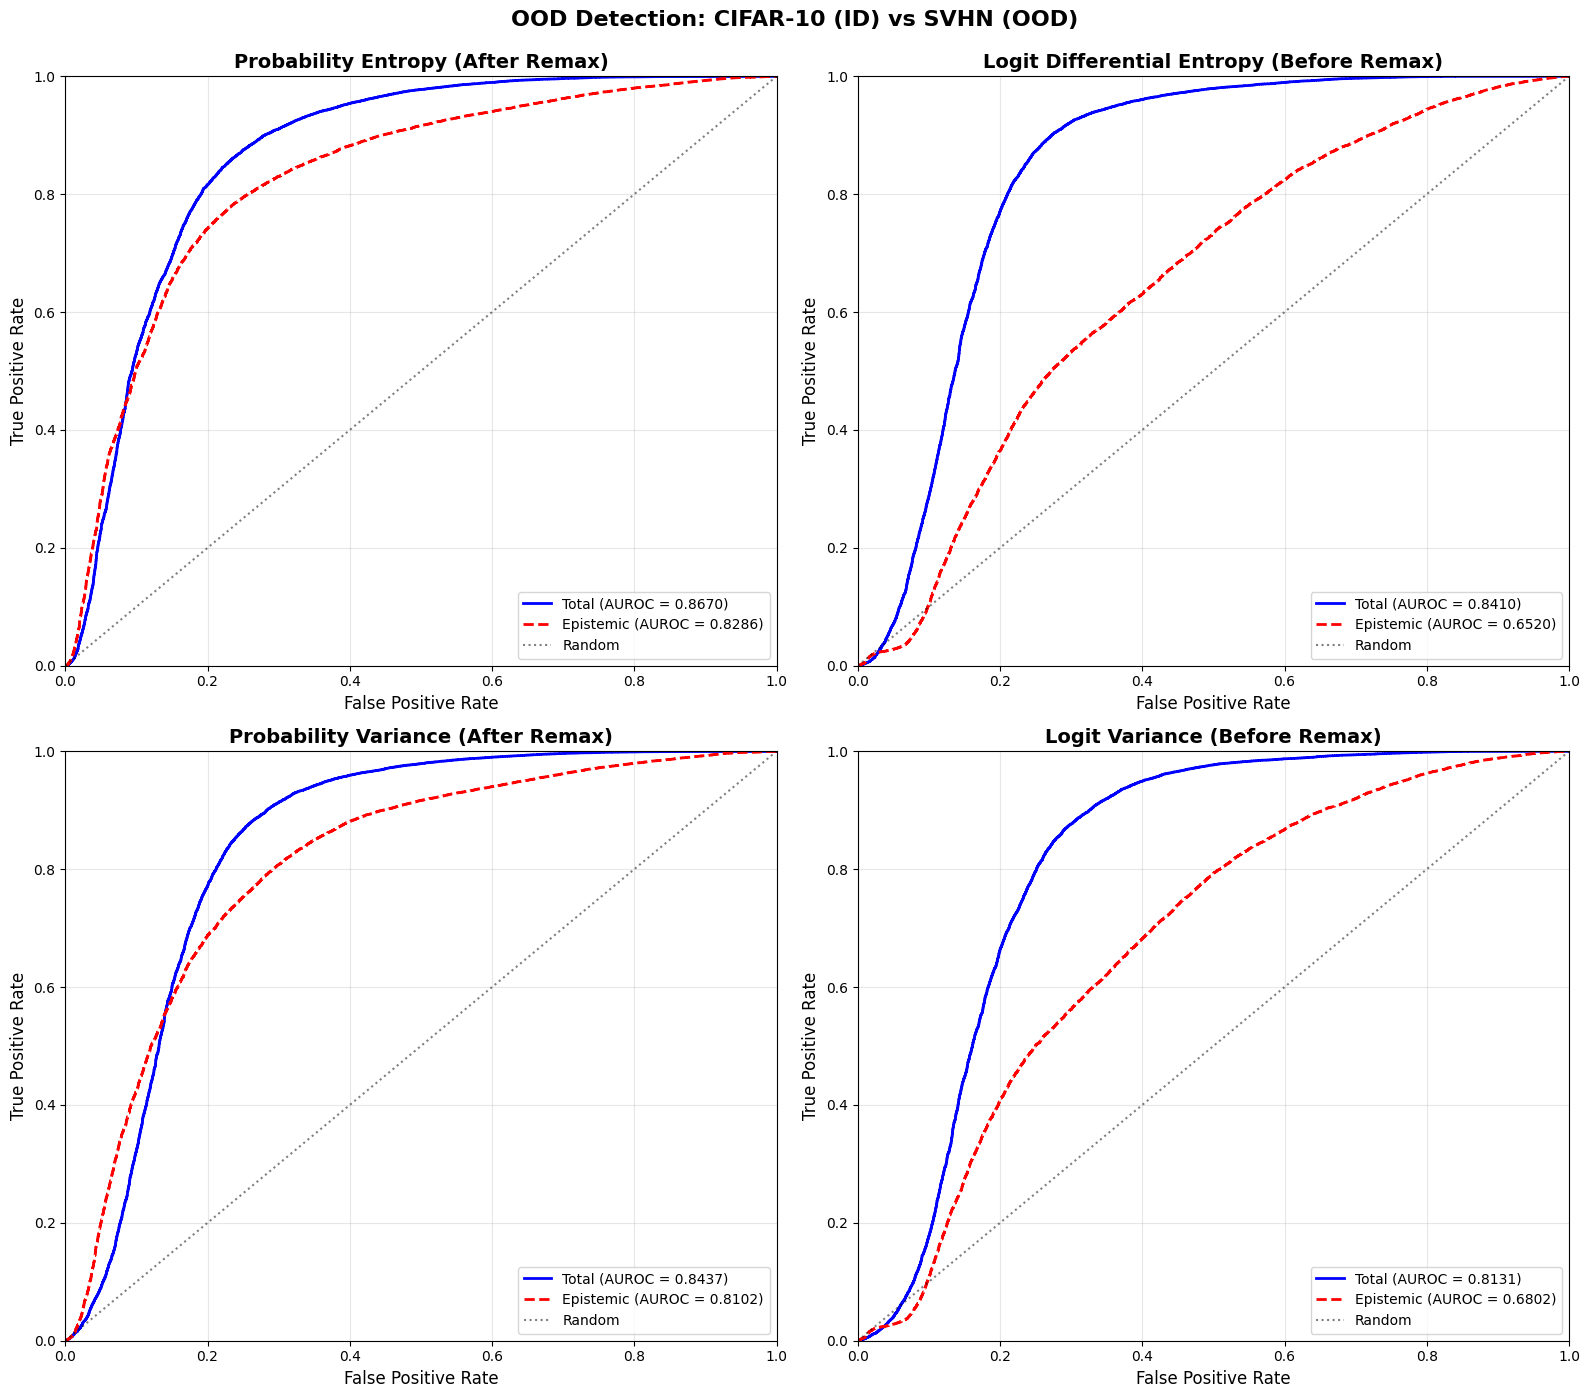


Plot saved to: ood_roc_svhn_comparison.png


In [ ]:
from sklearn.metrics import roc_curve, auc

def compute_auroc(id_scores, ood_scores):
    """
    Compute AUROC for OOD detection.
    Higher uncertainty score should indicate OOD.
    """
    labels = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
    scores = np.concatenate([id_scores, ood_scores])
    fpr, tpr, _ = roc_curve(labels, scores)
    auroc = auc(fpr, tpr)
    return fpr, tpr, auroc

# Compute ROC curves for all metrics - SVHN vs CIFAR-10
results_svhn = {}

# Total uncertainty
results_svhn['prob_entropy_total'] = compute_auroc(cifar_total['prob_entropy'], svhn_total['prob_entropy'])
results_svhn['logit_entropy_total'] = compute_auroc(cifar_total['logit_entropy'], svhn_total['logit_entropy'])
results_svhn['prob_var_total'] = compute_auroc(cifar_total['prob_variance'], svhn_total['prob_variance'])
results_svhn['logit_var_total'] = compute_auroc(cifar_total['logit_variance'], svhn_total['logit_variance'])

# Epistemic only
results_svhn['prob_entropy_epist'] = compute_auroc(cifar_epistemic['prob_entropy'], svhn_epistemic['prob_entropy'])
results_svhn['logit_entropy_epist'] = compute_auroc(cifar_epistemic['logit_entropy'], svhn_epistemic['logit_entropy'])
results_svhn['prob_var_epist'] = compute_auroc(cifar_epistemic['prob_variance'], svhn_epistemic['prob_variance'])
results_svhn['logit_var_epist'] = compute_auroc(cifar_epistemic['logit_variance'], svhn_epistemic['logit_variance'])

# Compute ROC curves for all metrics - Food-101 vs CIFAR-10
results_food = {}

# Total uncertainty
results_food['prob_entropy_total'] = compute_auroc(cifar_total['prob_entropy'], food_total['prob_entropy'])
results_food['logit_entropy_total'] = compute_auroc(cifar_total['logit_entropy'], food_total['logit_entropy'])
results_food['prob_var_total'] = compute_auroc(cifar_total['prob_variance'], food_total['prob_variance'])
results_food['logit_var_total'] = compute_auroc(cifar_total['logit_variance'], food_total['logit_variance'])

# Epistemic only
results_food['prob_entropy_epist'] = compute_auroc(cifar_epistemic['prob_entropy'], food_epistemic['prob_entropy'])
results_food['logit_entropy_epist'] = compute_auroc(cifar_epistemic['logit_entropy'], food_epistemic['logit_entropy'])
results_food['prob_var_epist'] = compute_auroc(cifar_epistemic['prob_variance'], food_epistemic['prob_variance'])
results_food['logit_var_epist'] = compute_auroc(cifar_epistemic['logit_variance'], food_epistemic['logit_variance'])

# Plot ROC curves - 2x2 grid comparing Probability vs Logit metrics
# First plot: SVHN (OOD) vs CIFAR-10 (ID)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('OOD Detection: CIFAR-10 (ID) vs SVHN (OOD)', fontsize=16, fontweight='bold', y=0.995)

# Top-Left: Probability Entropy
ax = axes[0, 0]
ax.plot(results_svhn['prob_entropy_total'][0], results_svhn['prob_entropy_total'][1], 'b-', linewidth=2, 
        label=f'Total (AUROC = {results_svhn["prob_entropy_total"][2]:.4f})')
ax.plot(results_svhn['prob_entropy_epist'][0], results_svhn['prob_entropy_epist'][1], 'r--', linewidth=2,
        label=f'Epistemic (AUROC = {results_svhn["prob_entropy_epist"][2]:.4f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
ax.set_title('Probability Entropy (After Remax)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Top-Right: Logit Entropy
ax = axes[0, 1]
ax.plot(results_svhn['logit_entropy_total'][0], results_svhn['logit_entropy_total'][1], 'b-', linewidth=2,
        label=f'Total (AUROC = {results_svhn["logit_entropy_total"][2]:.4f})')
ax.plot(results_svhn['logit_entropy_epist'][0], results_svhn['logit_entropy_epist'][1], 'r--', linewidth=2,
        label=f'Epistemic (AUROC = {results_svhn["logit_entropy_epist"][2]:.4f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
ax.set_title('Logit Differential Entropy (Before Remax)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Bottom-Left: Probability Variance
ax = axes[1, 0]
ax.plot(results_svhn['prob_var_total'][0], results_svhn['prob_var_total'][1], 'b-', linewidth=2,
        label=f'Total (AUROC = {results_svhn["prob_var_total"][2]:.4f})')
ax.plot(results_svhn['prob_var_epist'][0], results_svhn['prob_var_epist'][1], 'r--', linewidth=2,
        label=f'Epistemic (AUROC = {results_svhn["prob_var_epist"][2]:.4f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
ax.set_title('Probability Variance (After Remax)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Bottom-Right: Logit Variance
ax = axes[1, 1]
ax.plot(results_svhn['logit_var_total'][0], results_svhn['logit_var_total'][1], 'b-', linewidth=2,
        label=f'Total (AUROC = {results_svhn["logit_var_total"][2]:.4f})')
ax.plot(results_svhn['logit_var_epist'][0], results_svhn['logit_var_epist'][1], 'r--', linewidth=2,
        label=f'Epistemic (AUROC = {results_svhn["logit_var_epist"][2]:.4f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
ax.set_title('Logit Variance (Before Remax)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('ood_roc_svhn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: ood_roc_svhn_comparison.png")

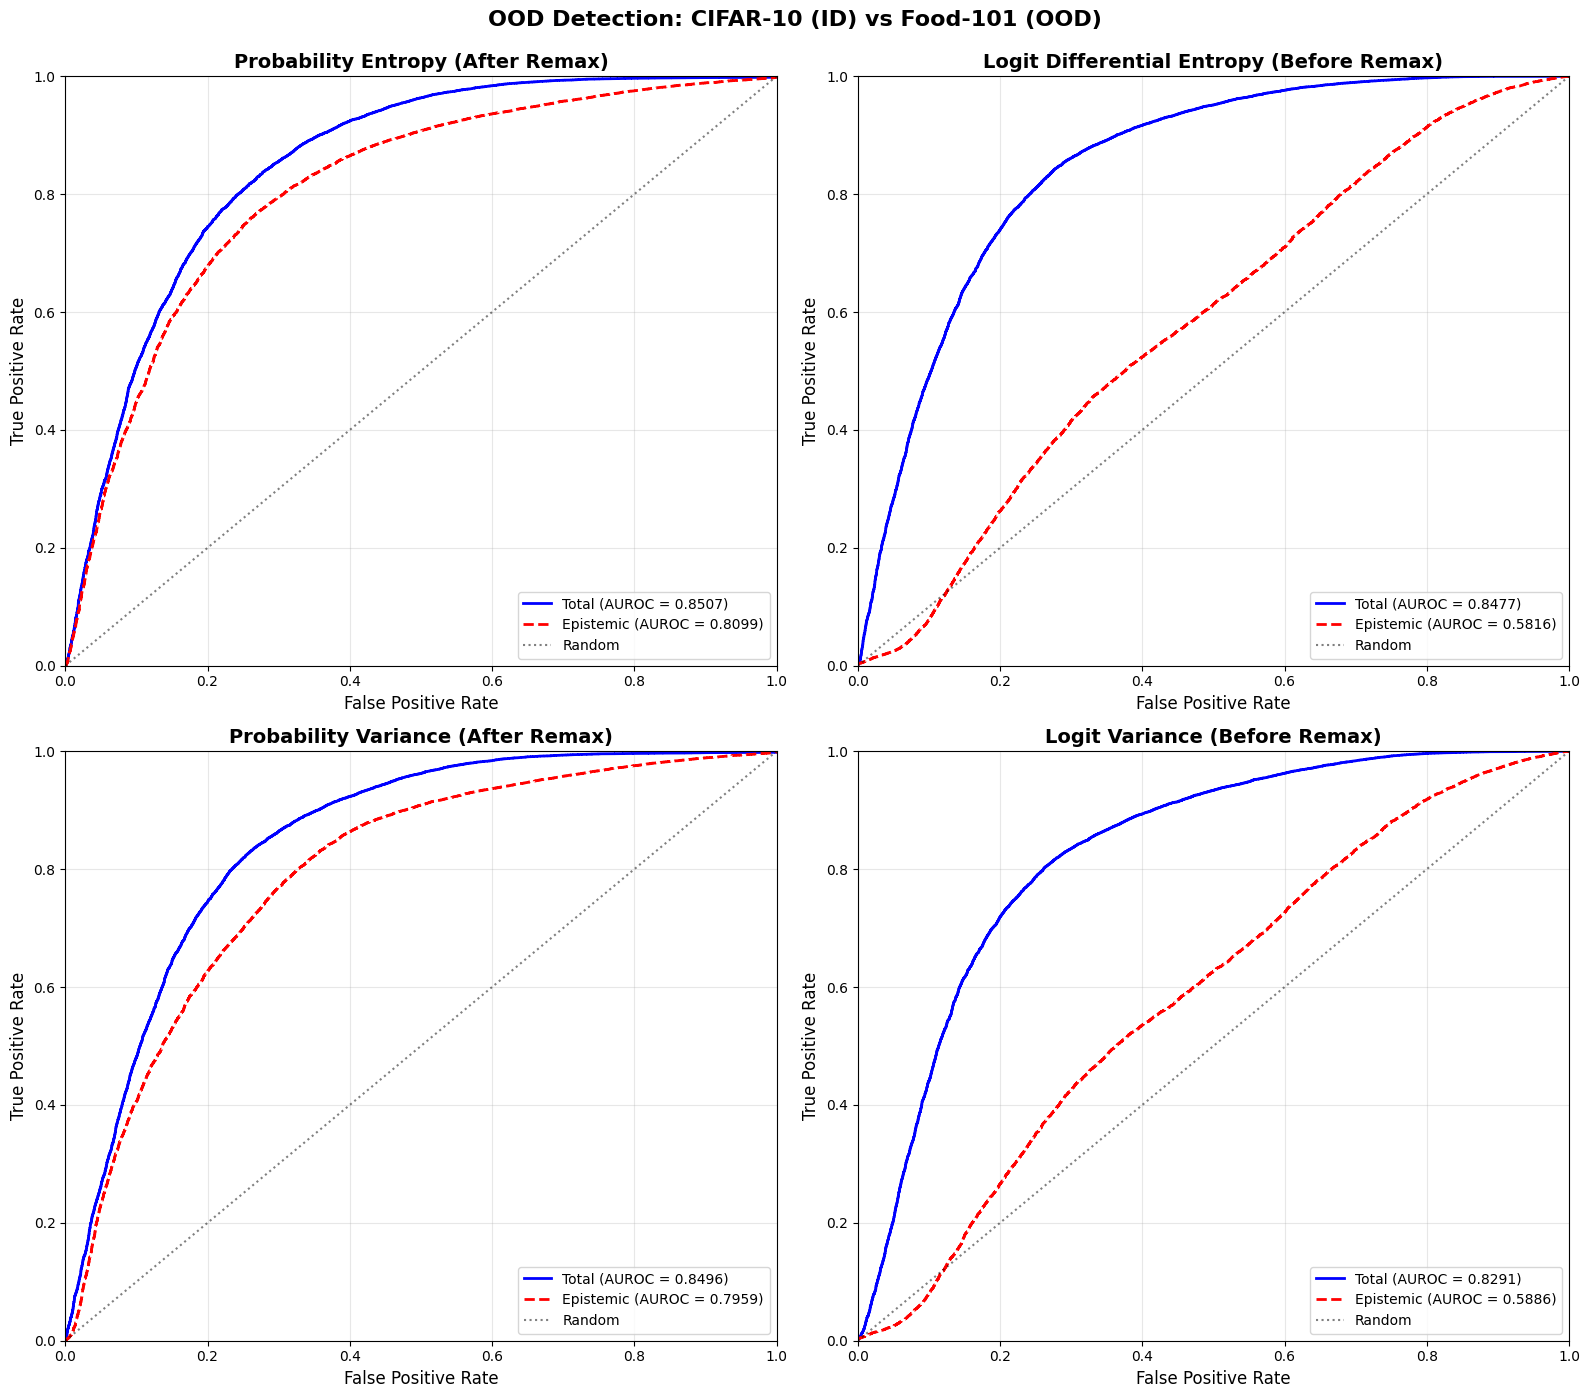


Plot saved to: ood_roc_food_comparison.png


In [ ]:
# Plot ROC curves - 2x2 grid comparing Probability vs Logit metrics
# Second plot: Food-101 (OOD) vs CIFAR-10 (ID)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('OOD Detection: CIFAR-10 (ID) vs Food-101 (OOD)', fontsize=16, fontweight='bold', y=0.995)

# Top-Left: Probability Entropy
ax = axes[0, 0]
ax.plot(results_food['prob_entropy_total'][0], results_food['prob_entropy_total'][1], 'b-', linewidth=2, 
        label=f'Total (AUROC = {results_food["prob_entropy_total"][2]:.4f})')
ax.plot(results_food['prob_entropy_epist'][0], results_food['prob_entropy_epist'][1], 'r--', linewidth=2,
        label=f'Epistemic (AUROC = {results_food["prob_entropy_epist"][2]:.4f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
ax.set_title('Probability Entropy (After Remax)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Top-Right: Logit Entropy
ax = axes[0, 1]
ax.plot(results_food['logit_entropy_total'][0], results_food['logit_entropy_total'][1], 'b-', linewidth=2,
        label=f'Total (AUROC = {results_food["logit_entropy_total"][2]:.4f})')
ax.plot(results_food['logit_entropy_epist'][0], results_food['logit_entropy_epist'][1], 'r--', linewidth=2,
        label=f'Epistemic (AUROC = {results_food["logit_entropy_epist"][2]:.4f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
ax.set_title('Logit Differential Entropy (Before Remax)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Bottom-Left: Probability Variance
ax = axes[1, 0]
ax.plot(results_food['prob_var_total'][0], results_food['prob_var_total'][1], 'b-', linewidth=2,
        label=f'Total (AUROC = {results_food["prob_var_total"][2]:.4f})')
ax.plot(results_food['prob_var_epist'][0], results_food['prob_var_epist'][1], 'r--', linewidth=2,
        label=f'Epistemic (AUROC = {results_food["prob_var_epist"][2]:.4f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
ax.set_title('Probability Variance (After Remax)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Bottom-Right: Logit Variance
ax = axes[1, 1]
ax.plot(results_food['logit_var_total'][0], results_food['logit_var_total'][1], 'b-', linewidth=2,
        label=f'Total (AUROC = {results_food["logit_var_total"][2]:.4f})')
ax.plot(results_food['logit_var_epist'][0], results_food['logit_var_epist'][1], 'r--', linewidth=2,
        label=f'Epistemic (AUROC = {results_food["logit_var_epist"][2]:.4f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
ax.set_title('Logit Variance (Before Remax)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('ood_roc_food_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: ood_roc_food_comparison.png")

In [ ]:
# Compute ROC curves for all metrics - Stanford Cars vs CIFAR-10
if cars_total is not None and cars_epistemic is not None:
    results_cars = {}
    
    # Total uncertainty
    results_cars['prob_entropy_total'] = compute_auroc(cifar_total['prob_entropy'], cars_total['prob_entropy'])
    results_cars['logit_entropy_total'] = compute_auroc(cifar_total['logit_entropy'], cars_total['logit_entropy'])
    results_cars['prob_var_total'] = compute_auroc(cifar_total['prob_variance'], cars_total['prob_variance'])
    results_cars['logit_var_total'] = compute_auroc(cifar_total['logit_variance'], cars_total['logit_variance'])
    
    # Epistemic only
    results_cars['prob_entropy_epist'] = compute_auroc(cifar_epistemic['prob_entropy'], cars_epistemic['prob_entropy'])
    results_cars['logit_entropy_epist'] = compute_auroc(cifar_epistemic['logit_entropy'], cars_epistemic['logit_entropy'])
    results_cars['prob_var_epist'] = compute_auroc(cifar_epistemic['prob_variance'], cars_epistemic['prob_variance'])
    results_cars['logit_var_epist'] = compute_auroc(cifar_epistemic['logit_variance'], cars_epistemic['logit_variance'])
else:
    results_cars = None

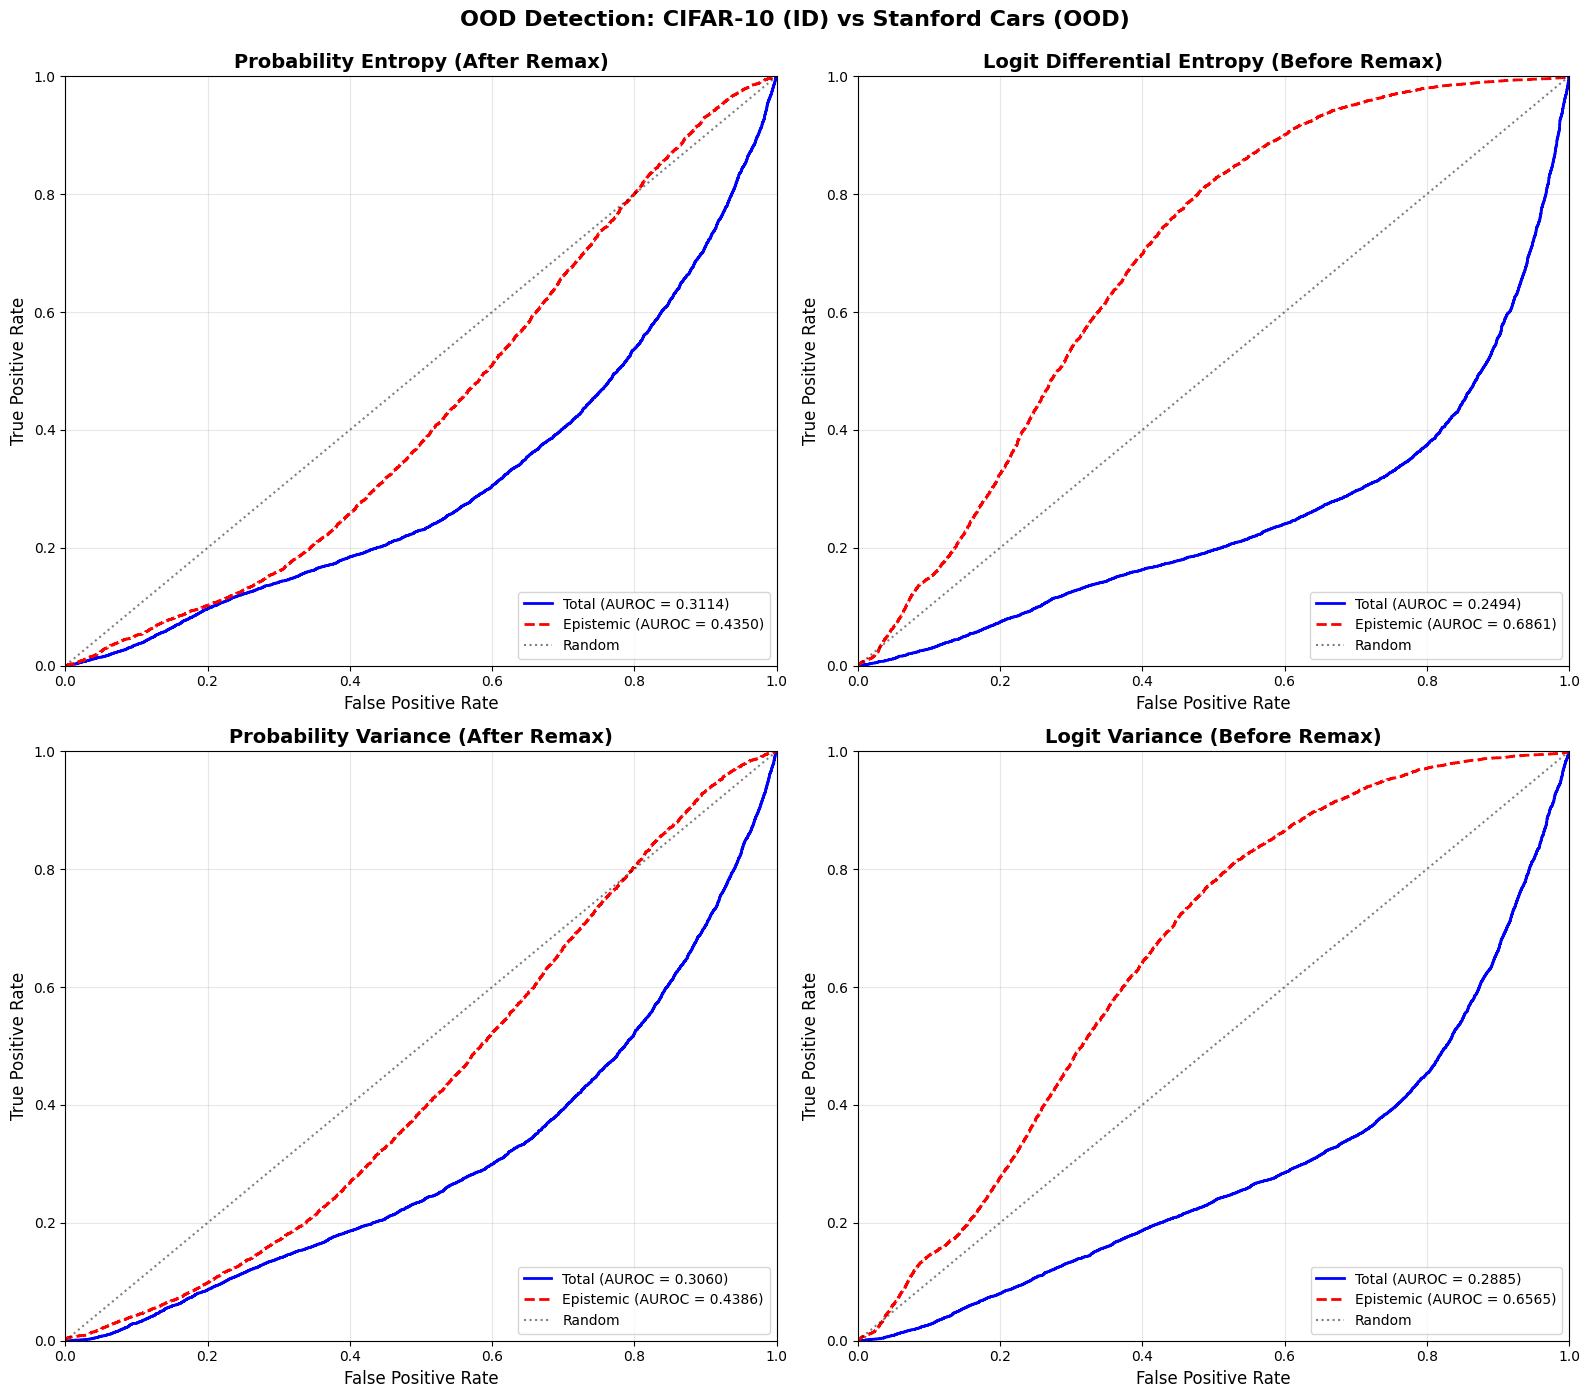


Plot saved to: ood_roc_cars_comparison.png


In [ ]:
# Plot ROC curves - 2x2 grid comparing Probability vs Logit metrics
# Third plot: Stanford Cars (OOD) vs CIFAR-10 (ID)
if results_cars is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle('OOD Detection: CIFAR-10 (ID) vs Stanford Cars (OOD)', fontsize=16, fontweight='bold', y=0.995)
    
    # Top-Left: Probability Entropy
    ax = axes[0, 0]
    ax.plot(results_cars['prob_entropy_total'][0], results_cars['prob_entropy_total'][1], 'b-', linewidth=2, 
            label=f'Total (AUROC = {results_cars["prob_entropy_total"][2]:.4f})')
    ax.plot(results_cars['prob_entropy_epist'][0], results_cars['prob_entropy_epist'][1], 'r--', linewidth=2,
            label=f'Epistemic (AUROC = {results_cars["prob_entropy_epist"][2]:.4f})')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
    ax.set_title('Probability Entropy (After Remax)', fontsize=14, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    # Top-Right: Logit Entropy
    ax = axes[0, 1]
    ax.plot(results_cars['logit_entropy_total'][0], results_cars['logit_entropy_total'][1], 'b-', linewidth=2,
            label=f'Total (AUROC = {results_cars["logit_entropy_total"][2]:.4f})')
    ax.plot(results_cars['logit_entropy_epist'][0], results_cars['logit_entropy_epist'][1], 'r--', linewidth=2,
            label=f'Epistemic (AUROC = {results_cars["logit_entropy_epist"][2]:.4f})')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
    ax.set_title('Logit Differential Entropy (Before Remax)', fontsize=14, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    # Bottom-Left: Probability Variance
    ax = axes[1, 0]
    ax.plot(results_cars['prob_var_total'][0], results_cars['prob_var_total'][1], 'b-', linewidth=2,
            label=f'Total (AUROC = {results_cars["prob_var_total"][2]:.4f})')
    ax.plot(results_cars['prob_var_epist'][0], results_cars['prob_var_epist'][1], 'r--', linewidth=2,
            label=f'Epistemic (AUROC = {results_cars["prob_var_epist"][2]:.4f})')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
    ax.set_title('Probability Variance (After Remax)', fontsize=14, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    # Bottom-Right: Logit Variance
    ax = axes[1, 1]
    ax.plot(results_cars['logit_var_total'][0], results_cars['logit_var_total'][1], 'b-', linewidth=2,
            label=f'Total (AUROC = {results_cars["logit_var_total"][2]:.4f})')
    ax.plot(results_cars['logit_var_epist'][0], results_cars['logit_var_epist'][1], 'r--', linewidth=2,
            label=f'Epistemic (AUROC = {results_cars["logit_var_epist"][2]:.4f})')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
    ax.set_title('Logit Variance (Before Remax)', fontsize=14, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig('ood_roc_cars_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nPlot saved to: ood_roc_cars_comparison.png")
else:
    print("Stanford Cars dataset not available - skipping ROC plot")

## Final Summary

In [ ]:
print("=" * 90)
print("OOD DETECTION PERFORMANCE SUMMARY (AUROC)")
print("=" * 90)

print("\nCIFAR-10 (ID) vs SVHN (OOD):")
print(f"\n{'Method':<50} {'Total':>12} {'Epistemic':>12}")
print("-" * 76)
print(f"{'Probability Entropy (After Remax)':<50} {results_svhn['prob_entropy_total'][2]:>12.4f} {results_svhn['prob_entropy_epist'][2]:>12.4f}")
print(f"{'Logit Differential Entropy (Before Remax)':<50} {results_svhn['logit_entropy_total'][2]:>12.4f} {results_svhn['logit_entropy_epist'][2]:>12.4f}")
print(f"{'Probability Variance (After Remax)':<50} {results_svhn['prob_var_total'][2]:>12.4f} {results_svhn['prob_var_epist'][2]:>12.4f}")
print(f"{'Logit Variance (Before Remax)':<50} {results_svhn['logit_var_total'][2]:>12.4f} {results_svhn['logit_var_epist'][2]:>12.4f}")

print("\n" + "-" * 90)
print("\nCIFAR-10 (ID) vs Food-101 (OOD):")
print(f"\n{'Method':<50} {'Total':>12} {'Epistemic':>12}")
print("-" * 76)
print(f"{'Probability Entropy (After Remax)':<50} {results_food['prob_entropy_total'][2]:>12.4f} {results_food['prob_entropy_epist'][2]:>12.4f}")
print(f"{'Logit Differential Entropy (Before Remax)':<50} {results_food['logit_entropy_total'][2]:>12.4f} {results_food['logit_entropy_epist'][2]:>12.4f}")
print(f"{'Probability Variance (After Remax)':<50} {results_food['prob_var_total'][2]:>12.4f} {results_food['prob_var_epist'][2]:>12.4f}")
print(f"{'Logit Variance (Before Remax)':<50} {results_food['logit_var_total'][2]:>12.4f} {results_food['logit_var_epist'][2]:>12.4f}")

print("=" * 90)

# Find best method
all_aurocs = {
    'Prob. Entropy (Total)': results['prob_entropy_total'][2],
    'Prob. Entropy (Epistemic)': results['prob_entropy_epist'][2],
    'Logit Entropy (Total)': results['logit_entropy_total'][2],
    'Logit Entropy (Epistemic)': results['logit_entropy_epist'][2],
    'Prob. Variance (Total)': results['prob_var_total'][2],
    'Prob. Variance (Epistemic)': results['prob_var_epist'][2],
    'Logit Variance (Total)': results['logit_var_total'][2],
    'Logit Variance (Epistemic)': results['logit_var_epist'][2],
}
best_method = max(all_aurocs, key=all_aurocs.get)
print(f"\nBest performing method: {best_method} with AUROC = {all_aurocs[best_method]:.4f}")

OOD DETECTION PERFORMANCE SUMMARY (AUROC)

CIFAR-10 (ID) vs SVHN (OOD):

Method                                                    Total    Epistemic
----------------------------------------------------------------------------
Probability Entropy (After Remax)                        0.8670       0.8286
Logit Differential Entropy (Before Remax)                0.8410       0.6520
Probability Variance (After Remax)                       0.8437       0.8102
Logit Variance (Before Remax)                            0.8131       0.6802

------------------------------------------------------------------------------------------

CIFAR-10 (ID) vs Food-101 (OOD):

Method                                                    Total    Epistemic
----------------------------------------------------------------------------
Probability Entropy (After Remax)                        0.8507       0.8099
Logit Differential Entropy (Before Remax)                0.8477       0.5816
Probability Variance (After Re

NameError: name 'results' is not defined